[이코드 내용]
- 데이터셋 eda를 gpt_api로 인사이트 도출
- 의료데이터 증강에 대하여
- val 자료가 턱없이 부족한 상황에서의 k-fold 기법 
    - 단 현재 작업은 val자료를 사용하지 않고 train데이터를 여러번 나누어서 val로 사용하는 기법임
    - 문제제시의 의도를 반영한 자료는 2번자료로 화인함

# Part1. 데이터 이해
```
# 코드로 형식 지정됨
```



## [cache]에 대하여
Colab에서 캐글(Kaggle) 데이터를 가져올 때, 일반적으로 루트 폴더(/content)가 아닌 .cache 폴더(숨김 폴더)나 라이브러리가 지정하는 캐시 경로에 저장하는 것에는 몇 가지 분명한 이유와 이점이 있습니다.

1. 반복 다운로드 방지 (시간 및 트래픽 절약)
- 가장 큰 이유는 효율성입니다.
- 작동 원리: datasets (Hugging Face)나 torch, kagglehub 같은 라이브러리들은 데이터를 다운로드할 때 먼저 캐시 디렉토리를 확인합니다.
- 이점: 코드 셀을 실수로 다시 실행하거나, 커널(Kernel)을 재시작하더라도 .cache에 파일이 남아 있다면 다시 다운로드하지 않고 즉시 로딩합니다. 이는 대용량 데이터셋을 다룰 때 시간을 획기적으로 단축해 줍니다.

2. 작업 공간(Workspace)의 청결 유지
- Colab의 파일 탐색기(왼쪽 사이드바)는 기본적으로 /content 경로를 보여줍니다.
- 이점: 데이터셋의 수천 개 이미지나 파일이 /content에 바로 풀리면, 내가 작성한 소스 코드나 결과 파일(.csv 등)을 찾기 매우 어려워집니다.
- 관리: .cache와 같이 .으로 시작하는 폴더는 숨김 폴더 처리되므로, 파일 탐색기를 깔끔하게 유지하면서 백그라운드에서 데이터를 관리할 수 있습니다.

3. 라이브러리 표준 준수 및 충돌 방지
- 많은 머신러닝 라이브러리들이 기본적으로 ~/.cache 경로를 사용하도록 설계되어 있습니다.
- 이점: 경로를 강제로 변경하지 않고 표준 캐시 경로를 사용하면, 라이브러리 간의 경로 꼬임이나 파일 못 찾음(File Not Found) 오류를 방지할 수 있습니다.

⚠️ 중요 주의사항: Colab의 휘발성
- Colab을 사용할 때 반드시 기억해야 할 점은 Colab의 디스크 공간(VM)은 휘발성이라는 것입니다.
- 문제점: .cache에 저장하든 /content에 저장하든, 런타임 연결이 해제되면(세션 종료 시) 모든 데이터는 삭제됩니다.
- 해결책 (영구 저장): 데이터를 영구적으로 보관하고 다음에 다시 다운로드하지 않으려면, 구글 드라이브를 마운트(Mount) 한 후 캐시 경로를 드라이브 쪽으로 변경해야 합니다.  (구글 드라이브가 속도가 빠름으로 상황에 따라서 꼭 드라이브 마운트 하지 않고,임시에서 작업해도 무방함)

In [1]:
#------------------------------
# 코렙다운로드가 빠른이유:
# 압도적인 다운로드 속도: Colab은 구글 서버망을 쓰기 때문에
# , 기가바이트(GB) 단위의 데이터도 수십 초~몇 분이면 다시 받습니다.
# ----------------------------------
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


## [폴더목록리스트 확인]

In [5]:
#------------------------------
# 추가: 폴더내부목록확인
#--------------------------------
import os
path = '/kaggle/input/chest-xray-pneumonia'
print(os.listdir(path))

['chest_xray']


In [7]:
#-------------------------------
# 추가 (다운로드 파일 확인)
# 터미널 또는 코렙주피터 셀에서 cd 명령으로 폴더구조를 확인합니다.
# !는 잠깐 쉘을 열어서 명령을 수행하고 닫는방식이라 pwd나, ls가 그 디렉토리가 표시되지 않음
# 영구적으로 이동하려면 % 매직커멘트를 사용해야함
# 매직커맨드: **매직 커맨드(Magic Command)**는 주피터 노트북(Jupyter Notebook)이나
#        구글 코랩(Colab) 환경에서만 사용할 수 있는 '특별한 기능 명령어'
#--------------------------------
%cd /kaggle/input/chest-xray-pneumonia
!ls
!pwd

/kaggle/input/chest-xray-pneumonia
chest_xray
/kaggle/input/chest-xray-pneumonia


In [13]:
#---------------------------------------
# 추가: 지정한 경로의 자료 확인 / 하단의 GPT코드와 겹침.. 코드 내용확인용
#----------------------------------------
import os  # 운영체제(OS)의 기능(파일 경로, 폴더 탐색 등)을 쓰기 위해 가져옵니다.

# 1. 탐색 시작 위치 설정
target_path = path  # path 변수에 담긴 경로('/kaggle/input/...')부터 탐색을 시작합니다.

# 2. 출력 제한 설정 (너무 많이 뜨는 것 방지)
max_files_view = 5  # 각 폴더마다 파일은 딱 5개까지만 보여주겠다고 설정합니다.

# 3. os.walk: 폴더 트리 탐색의 핵심 명령어
# target_path 안에 있는 모든 하위 폴더를 구석구석 방문합니다.
# 방문할 때마다 3가지 정보를 줍니다:
# root: 현재 방문 중인 폴더의 '전체 경로'
# dirs: 그 폴더 안에 있는 '하위 폴더 이름들' (리스트)
# files: 그 폴더 안에 있는 '파일 이름들' (리스트)
for root, dirs, files in os.walk(target_path):

    # 4. 들여쓰기(Indent) 계산: 폴더 깊이에 따라 공백을 주기 위함
    # 전체 경로(root)에서 시작 경로(target_path) 부분을 지웁니다.
    # 예: '/content/data/train' -> '/train'
    relative_path = root.replace(target_path, "")

    # 남은 경로에 구분자('/')가 몇 개인지 셉니다. 이게 곧 깊이(Level)가 됩니다.
    # os.sep: 윈도우는 '\', 리눅스/맥은 '/'를 자동으로 맞춰주는 변수입니다.
    level = relative_path.count(os.sep)

    # 깊이만큼 공백(스페이스 4칸)을 곱해서 들여쓰기를 만듭니다.
    indent = " " * 4 * (level)

    # 5. 폴더 이름 출력
    # os.path.basename(root): 긴 경로('/content/data/train')에서 마지막 폴더명('train')만 똑 떼어냅니다.
    print(f"{indent}{os.path.basename(root)}/")

    # 파일은 폴더보다 한 단계 더 안쪽에 있으니 들여쓰기를 한 번 더 합니다.
    subindent = " " * 4 * (level + 1)

    # 6. 파일 목록 출력 (핵심: 슬라이싱)
    # files[:max_files_view]: 파일 리스트 전체를 가져오지 않고, 앞에서부터 5개만 자릅니다.
    for f in files[:max_files_view]:
        print(f"{subindent}{f}")

    # 7. 생략된 파일 알림
    # 만약 파일 총 개수(len)가 5개보다 많다면, 나머지가 있다고 알려줍니다.
    if len(files) > max_files_view:
        print(f"{subindent}... (외 {len(files) - max_files_view}개 파일)")

chest-xray-pneumonia/
    chest_xray/
        chest_xray/
            .DS_Store
            val/
                .DS_Store
                PNEUMONIA/
                    person1947_bacteria_4876.jpeg
                    person1946_bacteria_4875.jpeg
                    person1952_bacteria_4883.jpeg
                    person1954_bacteria_4886.jpeg
                    person1951_bacteria_4882.jpeg
                    ... (외 4개 파일)
                NORMAL/
                    NORMAL2-IM-1431-0001.jpeg
                    NORMAL2-IM-1440-0001.jpeg
                    NORMAL2-IM-1442-0001.jpeg
                    NORMAL2-IM-1427-0001.jpeg
                    NORMAL2-IM-1430-0001.jpeg
                    ... (외 4개 파일)
            test/
                .DS_Store
                PNEUMONIA/
                    person1676_virus_2892.jpeg
                    person1650_virus_2852.jpeg
                    person22_virus_55.jpeg
                    person122_bacteria_582.jpeg
                    pe

## [GPT_API를 이용한 폴더목록 인사이트]

In [14]:
#----------------------------------------
# 추가: GPT_API로 분석하고자 할때
#---------------------------------------
!pip install openai

In [ ]:
#---------------------------------------
# 추가 GPT_API를 이용한 폴더구조 해석
#----------------------------------------
import os
from openai import OpenAI

# ==========================================
# 1. 설정 (API 키와 분석할 경로)
# ==========================================
my_api_key = "GPT API키"
target_path = '/kaggle/input/chest-xray-pneumonia'

client = OpenAI(api_key=my_api_key)

# ==========================================
# 2. 폴더 구조를 텍스트로 만드는 함수 (그대로 유지)
# ==========================================
def get_structure_text(path, max_files=3):
    output_lines = []
    for root, dirs, files in os.walk(path):
        if '__MACOSX' in root: continue # 불필요한 폴더 제외

        level = root.replace(path, '').count(os.sep)
        indent = ' ' * 4 * level
        folder_name = os.path.basename(root)
        output_lines.append(f"{indent}{folder_name}/")

        subindent = ' ' * 4 * (level + 1)
        for f in files[:max_files]:
            if f.startswith('.'): continue
            output_lines.append(f"{subindent}{f}")
        if len(files) > max_files:
            output_lines.append(f"{subindent}... (총 {len(files)}개 파일)")

    return "\n".join(output_lines)

# ==========================================
# 3. 실행: 한글 프롬프트 전송
# ==========================================
print(f" '{target_path}' 구조를 스캔 중입니다...")
structure_text = get_structure_text(target_path)

# [수정됨] Tasks를 한글로 변경
prompt = f"""
아래 텍스트는 이미지 분류 모델을 위한 데이터셋의 폴더 구조입니다.
이 구조를 시니어 데이터 사이언티스트의 관점에서 분석해주세요.

[분석 요청사항]
1. 데이터셋이 학습(Train), 테스트(Test), 검증(Val) 셋으로 잘 나뉘어 있는지, 클래스(Label)는 무엇인지 파악해주세요.
2. 각 폴더의 파일 개수 정보를 바탕으로 '데이터 불균형(Class Imbalance)' 문제가 있는지 확인해주세요.
3. PyTorch를 사용할 때 이 데이터를 로딩하는 가장 효율적인 방법(ImageFolder 등)을 추천해주세요.
4. 데이터 로딩 시 오류를 유발할 수 있는 불필요한 파일(Junk files)이 있는지 확인해주세요.

[폴더 구조]
{structure_text}
"""

print("🤖 GPT에게 한국어로 분석 요청을 보냅니다...")

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": "You are a helpful AI Data Scientist. Answer in Korean."},
        {"role": "user", "content": prompt}
    ]
)

print("\n" + "="*20 + " GPT 분석 결과 " + "="*20 + "\n")
print(response.choices[0].message.content)

📂 '/kaggle/input/chest-xray-pneumonia' 구조를 스캔 중입니다...
🤖 GPT에게 한국어로 분석 요청을 보냅니다...

==================== GPT 분석 결과 ====================

### 1. 데이터셋 구조 분석

주어진 폴더 구조를 분석해보면 `chest_xray` 내에 `train`, `test`, `val` 폴더가 있어 데이터셋이 학습, 테스트, 검증용으로 잘 나뉘어져 있습니다. 각 폴더는 두 개의 클래스, `PNEUMONIA`와 `NORMAL`로 분류되어 있으며, 이는 폐렴 여부를 판별하는 모델을 위한 데이터셋임을 알 수 있습니다.

### 2. 데이터 불균형 문제

파일 개수 정보를 기반으로 볼 때, 각 데이터셋의 클래스별 데이터 수는 다음과 같습니다:

- **Train Dataset**
  - PNEUMONIA: 3876개
  - NORMAL: 1342개

- **Test Dataset**
  - PNEUMONIA: 390개
  - NORMAL: 234개

- **Validation Dataset**
  - PNEUMONIA: 9개 (혹은 8개, 폴더별로 상이)
  - NORMAL: 9개 (혹은 8개, 폴더별로 상이)

이 데이터는 PNEUMONIA 클래스에 비해 NORMAL 클래스의 샘플이 적어 '데이터 불균형' 문제가 존재합니다. 이는 모델 학습 시 특정 클래스로 편향된 예측이 발생할 수 있음을 의미합니다. 이를 해결하기 위해서는 데이터 증강, 가중치 조정 및 데이터 언더샘플링 또는 오버샘플링 등의 방법을 고려해 볼 수 있습니다.

### 3. PyTorch를 활용한 데이터 로딩 방법

PyTorch에서는 `ImageFolder` 클래스를 이용하여 위와 같이 잘 정리된 폴더 구조의 데이터를 쉽게 로드할 수 있습니다. 예시 코드는 다음과 같습니다:

```python
from torchvision import datasets, transforms

# Transform 정의
trans

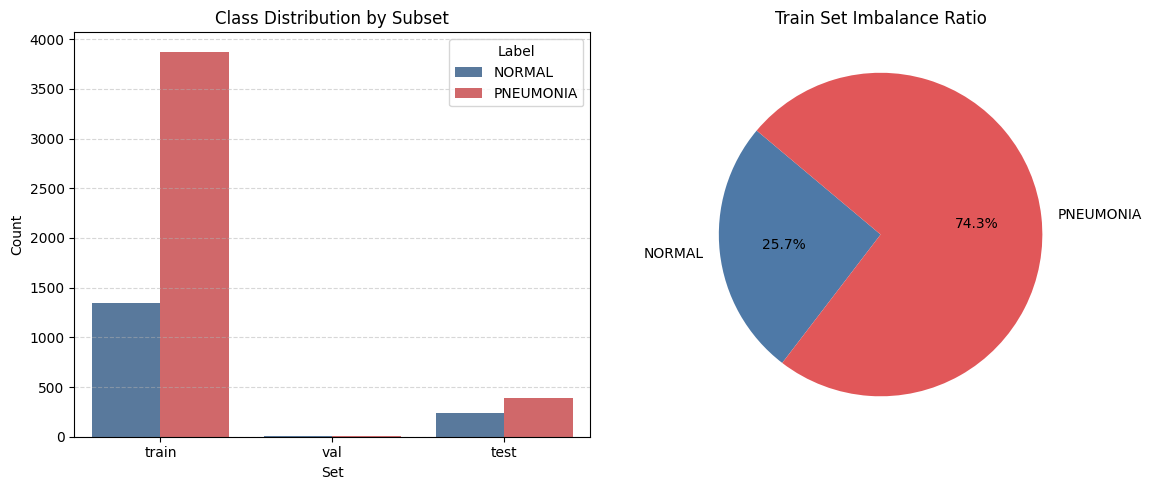

 [데이터 상세 수치]
     Set      Label  Count
0  train     NORMAL   1341
1  train  PNEUMONIA   3875
2    val     NORMAL      8
3    val  PNEUMONIA      8
4   test     NORMAL    234
5   test  PNEUMONIA    390

 [NORMAL 이미지 샘플]


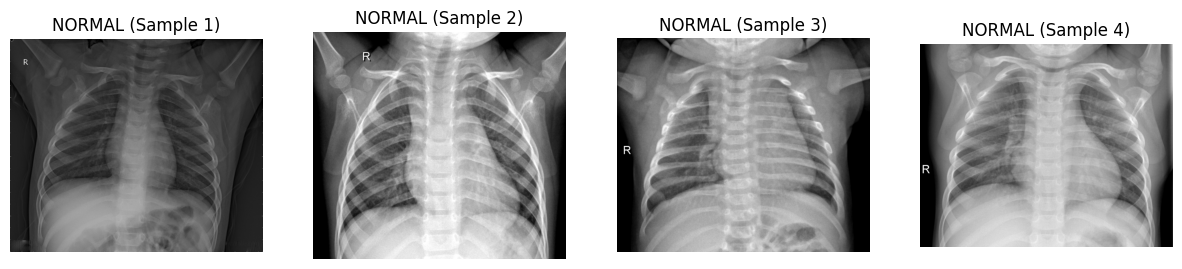


 [PNEUMONIA 이미지 샘플]


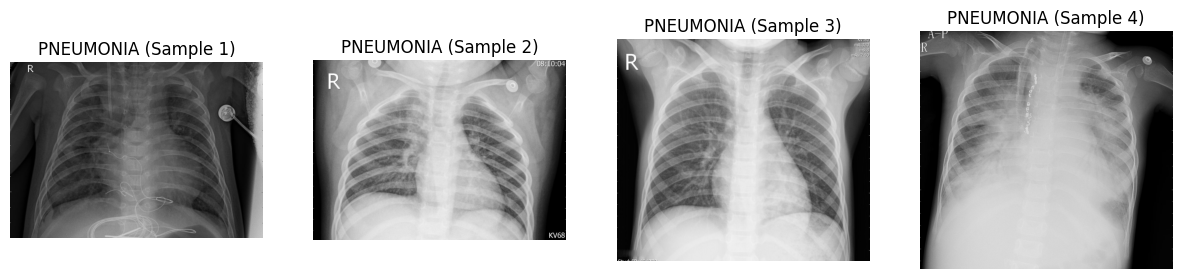

In [26]:
#-------------------------------
# 추가코드: 데이터 EDA
#--------------------------------

import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# ==========================================
# 1. 경로 설정 (중복된 폴더 구조 고려)
# ==========================================
base_path = Path('/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray') # 데이터 있는 실제 위치
# 만약 경로 에러가 나면 아래 경로로 시도해보세요:
# base_path = Path('/kaggle/input/chest-xray-pneumonia/chest_xray')

subsets = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

# ==========================================
# 2. 데이터 개수 집계 (불균형 확인)
# ==========================================
data_summary = []

for subset in subsets:
    for label in classes:
        folder_path = base_path / subset / label
        # 폴더 내의 이미지 파일(.jpeg, .jpg, .png) 개수 세기
        files = list(folder_path.glob('*.jpeg')) + list(folder_path.glob('*.jpg')) + list(folder_path.glob('*.png'))
        count = len(files)
        data_summary.append({'Set': subset, 'Label': label, 'Count': count})

df = pd.DataFrame(data_summary)

# ==========================================
# 3. 시각화 1: 데이터 분포 그래프
# ==========================================
plt.figure(figsize=(12, 5))

# (1) 전체 데이터셋 구성 비율
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Set', y='Count', hue='Label', palette=['#4E79A7', '#E15759'])
plt.title('Class Distribution by Subset')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# (2) Train 데이터 내부 비율 (파이 차트)
plt.subplot(1, 2, 2)
train_data = df[df['Set'] == 'train']
plt.pie(train_data['Count'], labels=train_data['Label'], autopct='%1.1f%%',
        colors=['#4E79A7', '#E15759'], startangle=140)
plt.title('Train Set Imbalance Ratio')

plt.tight_layout()
plt.show()

print("="*50)
print(" [데이터 상세 수치]")
print(df)
print("="*50)

# ==========================================
# 4. 시각화 2: 실제 이미지 샘플 보기
# ==========================================
def show_sample_images(label, num=4):
    folder_path = base_path / 'train' / label
    images = list(folder_path.glob('*.jpeg'))[:num]

    plt.figure(figsize=(15, 4))
    for i, img_path in enumerate(images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.title(f"{label} (Sample {i+1})")
        plt.axis('off')
    plt.show()

print("\n [NORMAL 이미지 샘플]")
show_sample_images('NORMAL')
print("\n [PNEUMONIA 이미지 샘플]")
show_sample_images('PNEUMONIA')

## [데이터EDA로 본 데이터불균형문제]
- val데이터셋이 작은경우 train 데이터를 val로 일부 옮겨도 되나. kaggle,와 같은 경진대회는 이런 방법을 허용하지 않음
- val이 적음으로 과적합에 신경써야함

          - 방법 1: Stratified K-Fold (추천)
            train 5,216개를 5등분해서 5번 학습/검증 반복
            val 8개는 너무 적어서 사용 ❌
            장점: 데이터 이동 없음, 검증 가장 정확함
            단점: 학습 시간 5배

          - 방법 2: Test를 Validation으로 사용
            train 5,216개로 학습
            test 624개를 validation처럼 사용
            장점: 학습 1번 → 빠름
            단점: test가 오염됨 → 최종 평가용으로 못 씀

          - 결론
            정확도가 중요 → 방법 1
            시간이 중요 → 방법 2

In [ ]:
from openai import OpenAI
import pandas as pd
from IPython.display import display, Markdown

# ==========================================
# 1. API 키 설정
# ==========================================
my_api_key = "GPT API키"
client = OpenAI(api_key=my_api_key)

# ==========================================
# 2. 데이터 현황 (이전 코드의 df가 있다고 가정)
# ==========================================
if 'df' not in locals():
    # 예시 데이터 (실제 상황 반영)
    data = {'Set': ['train', 'train', 'val', 'val', 'test', 'test'],
            'Label': ['NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA'],
            'Count': [1341, 3875, 8, 8, 234, 390]}
    df = pd.DataFrame(data)

df_string = df.to_markdown(index=False)

# ==========================================
# 3. [핵심] 전문 용어를 사용하되 논리적인 설명을 요구하는 프롬프트
# ==========================================
prompt = f"""
나는 딥러닝 코드 입문자야. 하지만 설명은 유치한 비유보다는 **정확한 기술 용어(Technical Terminology)**를 사용해서 엔지니어링 관점에서 해줘.
현재 진행 중인 폐렴 분류 프로젝트(Chest X-Ray Classification)의 데이터 분포를 보고 아래 문제점들을 분석하고 해결 코드를 제안해줘.

[데이터 분포]
{df_string}

[시스템 제약 사항]
* 데이터 저장소는 Read-only 상태임. (물리적 파일 이동/복사/삭제 불가)
* 반드시 파이썬/파이토치(PyTorch) **코드 레벨에서 논리적으로 분할**해야 함.

[분석 및 요청 사항]

1.  **Validation Set Under-representation (검증 데이터 과소 문제):**
    * 현재 `val` 데이터가 총 16장(정상 8, 폐렴 8)뿐임.
    * 이것이 모델의 **일반화 성능(Generalization Performance)** 평가와 **오버피팅(Overfitting)** 감지에 어떤 악영향을 미치는지 기술적으로 설명해줘.
    * '통계적 유의성(Statistical Significance)' 관점에서도 비판해줘.

2.  **Two-fold Imbalance Analysis (이중 불균형 분석):**
    * **Class Imbalance:** `Train` 셋 내에서 폐렴(3875) vs 정상(1341)의 비율 차이.
    * **Dataset Split Imbalance:** `Train` 셋(5000+장) 대비 `Val` 셋(16장)의 극단적인 비율 차이.

3.  **Solution: Stratified Split (계층적 분할):**
    * 물리적 이동 없이, `Train` 데이터셋을 **코드로 쪼개서(Split)** 신뢰할 수 있는 `Validation` 셋을 확보하는 방법을 알려줘.
    * 단순 `random_split`보다 클래스 비율을 유지하는 **`Stratified Split`** 방식이 왜 필요한지 설명하고, 이를 구현하는 `sklearn.model_selection.train_test_split`과 `Subset`을 활용한 예시 코드를 작성해줘.

4.  **Handling Class Imbalance:**
    * 학습 시 **`WeightedRandomSampler`** 또는 **`CrossEntropyLoss(weight=...)`**를 사용하여 클래스 불균형을 완화하는 전략을 코드로 보여줘.

답변 포맷: 기술적인 설명 후, 바로 복사해서 쓸 수 있는 Python 코드를 제시해줘.
"""

print(" 기술 멘토에게 전문적인 분석을 요청 중입니다...")

# ==========================================
# 4. GPT API 호출
# ==========================================
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": "You are a Senior Deep Learning Engineer. Use professional terminology but explain the logic clearly for a junior developer. Answer in Korean."},
        {"role": "user", "content": prompt}
    ]
)

# ==========================================
# 5. 결과 출력
# ==========================================
print("\n" + "="*20 + " 📋 엔지니어링 분석 리포트 " + "="*20 + "\n")
display(Markdown(response.choices[0].message.content))

 기술 멘토에게 전문적인 분석을 요청 중입니다...

==================== 📋 엔지니어링 분석 리포트 ====================



### 1. Validation Set Under-representation
검증 데이터의 부족은 모델의 일반화 성능을 정확하게 평가하는 데 문제를 야기합니다. 검증 데이터가 충분하지 않다면, 모델이 주어진 샘플에 잘 맞춰진(overfitted) 결과일 가능성이 높아지며, 실제 데이터에 대한 반응을 정확히 파악하기 어려워집니다. 통계적 유의성 차원에서도, 샘플 크기가 너무 작아 통계적 검토나 확신을 얻기 어려워집니다. 작은 검증 세트는 예측 성능에서 과소 추정 혹은 과대 추정을 초래할 수 있습니다.

### 2. Two-fold Imbalance Analysis
**Class Imbalance:** 클래스 불균형은 모델이 지배적인 클래스에 편향되어 예측 성향을 가지게 만듭니다. 즉, 데이터가 많은 클래스(PNEUMONIA)에서 높은 정확도를 보이나, 데이터가 적은 클래스(NORMAL)는 무시하는 현상이 발생할 수 있습니다.

**Dataset Split Imbalance:** 충분한 데이터를 검증 셋에서 확보하지 못하면 학습 데이터 분포와 평가 데이터 분포가 상이하게 됩니다. 이는 모델의 학습 과정 중 발생하는 과적합 문제를 사전에 평가하고 조정할 방법을 제공하지 못합니다.

### 3. Solution: Stratified Split
기존의 `random_split`은 클래스 비율이 유지되지 않아 불균형한 검증 및 테스트 셋을 만들기 쉽습니다. 이에 반해 `Stratified Split`은 데이터 라벨(Class Label)의 비율을 유지하며 분할하여 이러한 문제를 개선할 수 있습니다.

```python
import torch
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

# Dummy dataset assuming data is a list of (data, label) tuples
train_data = [(i, label) for i, (label) in enumerate(['NORMAL'] * 1341 + ['PNEUMONIA'] * 3875)]

# Extract labels for stratified split
labels = [label for _, label in train_data]

# Mapping labels to integers for stratified split
label_mapping = {'NORMAL': 0, 'PNEUMONIA': 1}
labels = [label_mapping[label] for label in labels]

# Perform Stratified Split
train_indices, val_indices = train_test_split(
    range(len(train_data)), test_size=0.1, stratify=labels, random_state=42)

# Create Subsets for train and validation
train_dataset = Subset(train_data, train_indices)
val_dataset = Subset(train_data, val_indices)

# Example DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
```

### 4. Handling Class Imbalance
다음의 방법들을 통해 클래스 불균형 문제를 해결할 수 있습니다:

- **WeightedRandomSampler:** 학습 중 샘플링 비율을 조정하여 균형을 맞춤.
- **CrossEntropyLoss(weight=...):** 손실 함수에 가중치를 추가하여 희귀 클래스를 더 중요하게 학습함.

```python
from torch.utils.data import WeightedRandomSampler
import torch.nn.functional as F

# Calculate class weights
class_counts = [1341, 3875]
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
samples_weights = class_weights[labels]

# Create Weighted Sampler
sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

# Modified DataLoader with Weighted Sampler
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)

# Example usage in training loop
# Assume output and target are tensors from your model and dataset
output = torch.randn(32, 2)  # Example model output
target = torch.randint(0, 2, (32,))  # Example target

# Loss with class weights
class_imbalance_weights = torch.tensor([1.0, 2.89])  # Example weights, adjust as needed
loss = F.cross_entropy(output, target, weight=class_imbalance_weights)
```

이와 같이 코드 레벨에서 불균형 문제를 해결하면 데이터의 실제 클래스 분포를 반영하여 보다 일반화된 모델을 구축할 수 있습니다.

## [의료데이터 증강 이해]

In [18]:
import torch
import os

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [19]:

train_dir = os.path.join(path, "chest_xray", "train")
val_dir = os.path.join(path, "chest_xray", "val")
test_dir = os.path.join(path, "chest_xray", "test")

train_dir

'/kaggle/input/chest-xray-pneumonia/chest_xray/train'

In [23]:
#=---------------------------
# 기존코드
#---------------------------------
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

transforms = v2.Compose(
    [
        v2.Resize((224, 224)),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
    ]
)

# 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=transforms)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 클래스 확인
class_names = train_dataset.classes
print("Class names:", class_names)

Class names: ['NORMAL', 'PNEUMONIA']


## [데이터증강에 대하여]

1. X-ray 데이터 증강 시 절대 하면 안 되는 것 (Bad Practice)
- 좌우 반전 (Horizontal Flip): 위험합니다.
  - 사람의 심장은 왼쪽(사진상 오른쪽)에 있습니다. 반전시키면 심장이 오른쪽에 있는 희귀병(우심증) 환자 데이터가 되어버립니다. 모델이 해부학적 위치를 헷갈리게 됩니다.

- 과도한 회전 (Rotation > 15도):
  - 환자가 눕거나 서서 찍을 때 약간 기울어질 순 있지만, 45도씩 돌아가는 경우는 없습니다.
  - 5도정도면 누워서 고개를 돌리는 정도임 ( v2.RandomRotation(degrees=5),)

- 임의의 잘라내기 (RandomCrop):
  - 폐렴 병변이 있는 부위를 잘라내 버리고 정상 부위만 남기면, 라벨은 '폐렴'인데 이미지는 '정상'인 잘못된 데이터가 됩니다.

2.의료 데이터에 적합한 "안전한 증강" (Best Practice)
- 의료 데이터에서는 "촬영 환경의 변화(조명, 환자의 미세한 움직임)" 정도만 흉내 내는 것이 정석입니다.

In [34]:
#------------------------------------
# 추가
#-----------------------------------
import os
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

# ==========================================
# 1. 설정 (경로 및 하이퍼파라미터)
# ==========================================
# 실제 데이터 경로 (아까 확인한 경로)
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
NUM_WORKERS = os.cpu_count() # 코랩의 모든 CPU 코어 사용

# ImageNet 학습 모델들이 사용하는 표준 통계값
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# ==========================================
# 2. Transforms (전처리 및 증강)
# ==========================================

# [학습용] - 안전한 증강 적용
train_transforms = v2.Compose([
    v2.Resize(IMAGE_SIZE),

    # -----------------------------------------------------------
    #  전체사진이 사진이 아니라, 폐사진만임으로 회전은 불필요할것으로 사료됨
    # -----------------------------------------------------------
    # 1. 이동 (Translation): 상하좌우로 10% 이내로만 살짝 이동
    # (카메라 앵글이나 중력 방향을 해치지 않음)
    # 이미지를 기울이지 않고(degrees=0), 가로·세로 방향으로 최대 10%(0.1)만 랜덤 이동시키는
    # 데이터 증강
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),

    # 2. 밝기/대비 (ColorJitter): 촬영 장비 선량 차이 시뮬레이션
    # 밝기 10% 변화 + 대비 10% 변화를 랜덤하게 적용하는 증강.
    v2.ColorJitter(brightness=0.1, contrast=0.1),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std) # 정규화
])

# [검증/테스트용] - 증강 없음 (원본 그대로 평가)
val_transforms = v2.Compose([
    v2.Resize(IMAGE_SIZE),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
])

# ==========================================
# 3. 데이터셋 로드 (ImageFolder)
# ==========================================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

# ==========================================
# 4. DataLoader 생성 (배치 단위 로딩)
# ==========================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # 학습 때는 순서를 섞어야 함
    num_workers=NUM_WORKERS,
    pin_memory=True         # GPU 전송 속도 향상
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # 검증 때는 섞을 필요 없음
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ==========================================
# 5. 결과 확인
# ==========================================
class_names = train_dataset.classes
print(f"클래스 이름: {class_names}")
print(f"학습 데이터 개수: {len(train_dataset)}장")
print(f"검증 데이터 개수: {len(val_dataset)}장")
print(f"테스트 데이터 개수: {len(test_dataset)}장")

클래스 이름: ['NORMAL', 'PNEUMONIA']
학습 데이터 개수: 5216장
검증 데이터 개수: 16장
테스트 데이터 개수: 624장


# Part2. 모델구성-여기서부터가 실제코드임

## [데이터로더-kfold-custom CNN모델 사용]

## [이코드로 실행시]
- fold값에 따른 편차가 있을수 있음
  - Fold 1: 91% (운 좋음)
  - Fold 2: 83% (초기화가 잘 안 됨)
  - Fold 3: 88% ...

-  "학습 데이터만 외우는 현상" (Overfitting 위험)
  - 현 모델에는 Dropout이나 Batch Normalization 같은 '과적합 방지 장치'가 없음

          - 결과가 90% 이상이다? 굳이 무거운 ResNet 쓸 필요 없습니다. 이 모델을 조금만 다듬어서 사용
          - 결과가 80% 대이거나 불안하다? "ResNet18로 모델 교체"하거나,
             현재 모델에 BatchNorm2d를 추가하면 성능이 확 오릅니다.


In [40]:
#----------------------------------------
# 베이스라인 코드임
#----------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

# Custom CNN 모델 정의
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # 입력 채널: 3, 출력 채널: 32
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                  # MaxPooling
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) # Conv2D
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))                       # Adaptive Pooling (7x7)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)                             # Fully Connected Layer
        self.fc2 = nn.Linear(128, num_classes)                            # Output Layer

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Conv1 + Pooling
        x = self.pool(F.relu(self.conv2(x)))  # Conv2 + Pooling
        x = self.avgpool(x)                   # Adaptive Pooling
        x = torch.flatten(x, 1)               # Flattening
        x = F.relu(self.fc1(x))               # Fully Connected Layer 1
        x = self.fc2(x)                       # Output Layer
        return x

# 클래스 수 설정 (NORMAL, PNEUMONIA)
num_classes = len(class_names)

## [k-fold]
1. 라이브러리 임포트: PyTorch, 데이터 처리, K-Fold에 필요한 모듈들 불러오기
2. Wrapper Class: train/val에 각각 다른 augmentation 적용하기 위한 클래스
  - 기존 클래스 포장해서 기능을 추가하는 클래스
  - Subset에 transform 기능을 추가로 씌워주는 포장지 역할의 클래스
3. 설정 및 하이퍼파라미터: GPU 설정, 데이터 경로, 배치 크기, 에폭 수 등 정의
4. Transform 정의: train은 증강(회전, 밝기 등), val은 정규화만 적용
5. 데이터 로드 및 불균형 처리: 전체 데이터 불러오고 NORMAL/PNEUMONIA 비율 맞춰 가중치 계산
6. 학습 함수: 1개 Fold를 학습하고 최고 검증 정확도 반환
7. K-Fold 실행: 5번 반복 학습하고 평균 정확도 출력
  - train 데이터 5,216개를 5등분
  - 각 Fold마다: 4개 묶음(약 4,173개)으로 학습, 1개 묶음(약 1,043개)으로 검증
  - 총 5번 학습 → 평균 정확도 계산

In [41]:
#========================================
# 1. 라이브러리 임포트
#========================================
import os                                    # 파일 경로 처리용
import numpy as np                           # 수치 연산용
import copy                                  # 객체 복사용 (현재 코드에서는 미사용)
import torch                                 # PyTorch 메인 라이브러리
import torch.nn as nn                        # 신경망 모듈 (Layer, Loss 등)
import torch.optim as optim                  # 최적화 알고리즘 (Adam, SGD 등)
from torch.utils.data import DataLoader, Subset, Dataset
# DataLoader: 배치 단위로 데이터 로드
# Subset: 데이터셋의 일부만 추출
# Dataset: 커스텀 데이터셋 클래스 상속용
from torchvision import datasets             # 이미지 데이터셋 로드 (ImageFolder 등)
from torchvision.transforms import v2        # 이미지 전처리/증강 (v2는 최신 버전)
from sklearn.model_selection import StratifiedKFold
# StratifiedKFold: 클래스 비율 유지하며 K-Fold 분할


#========================================
# 2. Wrapper Class 정의
#========================================
class TransformedSubset(Dataset):
    """
    Subset에 transform을 적용하기 위한 래퍼 클래스

    왜 필요한가?
    - ImageFolder로 로드한 데이터를 Subset으로 나누면 transform이 적용 안 됨
    - K-Fold에서 train/val 각각 다른 augmentation을 적용하려면 이 클래스 필요

    예시:
    - train: augmentation O (회전, 밝기 조정 등)
    - val: augmentation X (원본 이미지만 정규화)
    """
    def __init__(self, subset, transform=None):
        """
        Args:
            subset: torch.utils.data.Subset 객체 (원본 데이터의 일부)
            transform: 적용할 전처리/증강 함수 (v2.Compose 객체)
        """
        self.subset = subset          # 원본 Subset 저장
        self.transform = transform    # 적용할 transform 저장

    def __getitem__(self, index):
        """
        인덱스로 데이터를 가져올 때 호출되는 함수
        DataLoader가 배치를 만들 때 자동으로 호출됨
        """
        x, y = self.subset[index]     # 원본 데이터셋에서 (이미지, 라벨) 가져옴
        if self.transform:
            x = self.transform(x)      # transform이 있으면 이미지에 적용
        return x, y                    # 변환된 이미지와 라벨 반환

    def __len__(self):
        """데이터셋 크기 반환 (DataLoader가 전체 길이 알기 위해 필요)"""
        return len(self.subset)


#========================================
# 3. 설정 및 하이퍼파라미터
#========================================
# 디바이스 설정 (GPU 있으면 GPU, 없으면 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 데이터 경로 설정
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray'
train_dir = os.path.join(base_dir, 'train')  # train 폴더 경로

# 하이퍼파라미터
BATCH_SIZE = 32         # 한 번에 처리할 이미지 개수 (GPU 메모리에 따라 조정)
NUM_EPOCHS = 5          # 전체 데이터를 몇 번 반복 학습할지 (테스트용 5, 실전 10~20)
LEARNING_RATE = 0.001   # 학습률 (너무 크면 발산, 너무 작으면 느림)
N_SPLITS = 5            # K-Fold의 K값 (5-Fold = 5번 학습)


#========================================
# 4. 데이터 전처리 Transform 정의
#========================================
# ImageNet 데이터셋의 평균/표준편차 (전이학습 시 일반적으로 사용)
mean = [0.485, 0.456, 0.406]  # RGB 각 채널의 평균
std = [0.229, 0.224, 0.225]   # RGB 각 채널의 표준편차

# Train용 Transform (Data Augmentation 포함)
train_transform = v2.Compose([
    # 1. 크기 조정: 모든 이미지를 224x224로 통일 (CNN 입력 크기 고정 필요)
    v2.Resize((224, 224)),

    # 2. 랜덤 이동: 이미지를 최대 10%까지 랜덤하게 이동 (과적합 방지)
    #    degrees=0: 회전 안 함, translate=(0.1, 0.1): 가로/세로 10% 이동
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),

    # 3. 색상 변화: 밝기와 대비를 랜덤하게 조정 (다양한 조명 조건 시뮬레이션)
    #    brightness=0.1: ±10% 밝기 변화
    #    contrast=0.1: ±10% 대비 변화
    v2.ColorJitter(brightness=0.1, contrast=0.1),

    # 4. PIL Image → Tensor 변환
    v2.ToImage(),

    # 5. Tensor를 float32로 변환 + [0, 255] → [0, 1] 정규화
    v2.ToDtype(torch.float32, scale=True),

    # 6. 표준화: (pixel - mean) / std (모델 학습 안정화)
    v2.Normalize(mean=mean, std=std)
])

# Validation용 Transform (Augmentation 없음 - 원본 이미지 평가)
val_transform = v2.Compose([
    v2.Resize((224, 224)),              # 크기만 맞춤
    v2.ToImage(),                       # Tensor 변환
    v2.ToDtype(torch.float32, scale=True),  # 정규화
    v2.Normalize(mean=mean, std=std)    # 표준화
    # 주의: RandomAffine, ColorJitter 없음 (검증은 원본으로)
])


#========================================
# 5. 데이터 로드 및 클래스 불균형 처리
#========================================
# 전체 train 데이터 로드
# transform=None: 일단 원본으로 로드 (나중에 TransformedSubset에서 적용)
# ImageFolder는 폴더 구조로 자동 라벨링: train/NORMAL/*.jpg → label 0
#                                      train/PNEUMONIA/*.jpg → label 1
full_dataset = datasets.ImageFolder(train_dir, transform=None)
targets = full_dataset.targets  # 모든 이미지의 라벨 리스트 [0, 1, 1, 0, ...]

# 클래스별 샘플 수 계산
count_normal = targets.count(0)        # NORMAL 클래스 개수: 1341
count_pneumonia = targets.count(1)     # PNEUMONIA 클래스 개수: 3875

# 클래스 불균형 가중치 계산
# 목적: 소수 클래스(NORMAL)의 loss에 더 큰 가중치를 줘서 균형 맞추기
# weight_normal = 3875 / 1341 ≈ 2.89 (NORMAL의 loss를 2.89배 중요하게)
# weight_pneumonia = 1.0 (기준값)
weight_normal = count_pneumonia / count_normal
class_weights = torch.tensor([weight_normal, 1.0]).to(device)
# 결과: [2.89, 1.0] → CrossEntropyLoss에 전달


#========================================
# 6. 학습 함수 (1개 Fold용)
#========================================
def train_custom_cnn_fold(fold_idx, train_loader, val_loader):
    """
    한 개의 Fold를 학습하고 최고 validation accuracy 반환

    Args:
        fold_idx: 현재 Fold 번호 (0~4)
        train_loader: 이번 Fold의 학습 데이터 로더
        val_loader: 이번 Fold의 검증 데이터 로더

    Returns:
        best_acc: 이번 Fold에서 달성한 최고 검증 정확도
    """
    # 모델 초기화 (매 Fold마다 새로 생성 - 이전 Fold 영향 제거)
    model = CustomCNN(num_classes=2).to(device)

    # 손실 함수: 클래스 불균형 가중치 적용
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # 최적화 알고리즘: Adam (학습률 0.001)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 최고 정확도 추적 변수
    best_acc = 0.0

    print(f"\n--- [Fold {fold_idx+1}] 학습 시작 ---")

    # Epoch 반복 (전체 데이터를 NUM_EPOCHS번 학습)
    for epoch in range(NUM_EPOCHS):

        # ===== Train Phase (학습 모드) =====
        model.train()  # Dropout, BatchNorm 등을 학습 모드로 설정
        running_corrects = 0  # 맞춘 샘플 수 누적

        # 배치 단위로 데이터 로드
        for inputs, labels in train_loader:
            # GPU로 데이터 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. 이전 배치의 gradient 초기화
            optimizer.zero_grad()

            # 2. Forward pass: 모델 예측
            outputs = model(inputs)  # shape: [batch_size, 2]

            # 3. Loss 계산
            loss = criterion(outputs, labels)

            # 4. Backward pass: gradient 계산
            loss.backward()

            # 5. 가중치 업데이트
            optimizer.step()

            # 6. 정확도 계산을 위해 예측 클래스 추출
            _, preds = torch.max(outputs, 1)  # 가장 높은 확률의 클래스
            running_corrects += torch.sum(preds == labels.data)

        # Train Accuracy 계산
        train_acc = running_corrects.double() / len(train_loader.dataset)

        # ===== Validation Phase (평가 모드) =====
        model.eval()  # Dropout 비활성화, BatchNorm은 학습된 평균/분산 사용
        val_corrects = 0

        # gradient 계산 안 함 (메모리 절약 + 속도 향상)
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass만 수행 (backward 없음)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)

        # Validation Accuracy 계산
        val_acc = val_corrects.double() / len(val_loader.dataset)

        # 진행 상황 출력
        print(f"Ep {epoch+1} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

        # Best 모델 기록 (검증 정확도가 이전보다 높으면 갱신)
        if val_acc > best_acc:
            best_acc = val_acc
            # 필요시 여기서 모델 저장: torch.save(model.state_dict(), f'best_fold{fold_idx}.pth')

    return best_acc  # 이번 Fold의 최고 정확도 반환


#========================================
# 7. K-Fold Cross Validation 실행
#========================================
# StratifiedKFold 객체 생성
# n_splits=5: 데이터를 5등분
# shuffle=True: 분할 전에 데이터 섞기
# random_state=42: 재현성을 위한 시드 고정
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# 각 Fold의 결과를 저장할 리스트
fold_results = []

print(f"총 {N_SPLITS}번의 교차 검증 시작...")

# K-Fold 반복 (5번 학습)
# split() 함수가 (train_indices, val_indices) 튜플을 반환
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    # np.zeros(len(targets)): StratifiedKFold은 X(특징)가 필요하지만 사용 안 함
    # targets: 라벨로 클래스 비율 유지하며 분할

    # 이번 Fold의 train/val 인덱스로 Subset 생성 후 Transform 적용
    # Subset(full_dataset, train_idx): 전체 데이터에서 train_idx에 해당하는 것만 추출
    # TransformedSubset(..., transform=train_transform): train augmentation 적용
    train_ds = TransformedSubset(Subset(full_dataset, train_idx), transform=train_transform)
    val_ds = TransformedSubset(Subset(full_dataset, val_idx), transform=val_transform)

    # DataLoader 생성
    # shuffle=True (train만): 배치마다 순서를 섞어서 학습
    # num_workers=2: 멀티프로세싱으로 데이터 로드 속도 향상
    # pin_memory=True: GPU 전송 속도 향상 (CUDA 사용 시)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

    # 이번 Fold 학습 실행
    acc = train_custom_cnn_fold(fold, train_loader, val_loader)
    fold_results.append(acc)  # 결과 저장

# 5개 Fold의 평균 정확도 계산 및 출력
print(f"\n최종 평균 정확도: {np.mean(fold_results):.4f}")
# 예시: Fold별로 [0.85, 0.87, 0.86, 0.88, 0.84] → 평균 0.86

 총 5번의 교차 검증 시작...

--- [Fold 1] 학습 시작 ---
Ep 1 | Train: 0.7627 | Val: 0.8736
Ep 2 | Train: 0.8945 | Val: 0.9416
Ep 3 | Train: 0.9147 | Val: 0.9272
Ep 4 | Train: 0.9226 | Val: 0.9215
Ep 5 | Train: 0.9183 | Val: 0.9550

--- [Fold 2] 학습 시작 ---
Ep 1 | Train: 0.7774 | Val: 0.9223
Ep 2 | Train: 0.8867 | Val: 0.9386
Ep 3 | Train: 0.9041 | Val: 0.9607
Ep 4 | Train: 0.9188 | Val: 0.9607
Ep 5 | Train: 0.9250 | Val: 0.9396

--- [Fold 3] 학습 시작 ---
Ep 1 | Train: 0.6662 | Val: 0.8006
Ep 2 | Train: 0.8711 | Val: 0.8907
Ep 3 | Train: 0.9156 | Val: 0.8284
Ep 4 | Train: 0.9156 | Val: 0.9233
Ep 5 | Train: 0.9176 | Val: 0.9453

--- [Fold 4] 학습 시작 ---
Ep 1 | Train: 0.7954 | Val: 0.9271
Ep 2 | Train: 0.9046 | Val: 0.9616
Ep 3 | Train: 0.9197 | Val: 0.8993
Ep 4 | Train: 0.9224 | Val: 0.9636
Ep 5 | Train: 0.9353 | Val: 0.9492

--- [Fold 5] 학습 시작 ---
Ep 1 | Train: 0.7534 | Val: 0.9300
Ep 2 | Train: 0.9022 | Val: 0.9511
Ep 3 | Train: 0.9188 | Val: 0.9540
Ep 4 | Train: 0.9286 | Val: 0.9530
Ep 5 | Train: 0.9298 

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [42]:
# 위의 에러 해결
# GPU에 있는 텐서들을 CPU 숫자로 변환
# (에러가 나서 결과를 못 봤던 fold_results를 구조해냅니다)
final_results = [x.item() if isinstance(x, torch.Tensor) else x for x in fold_results]

print("="*40)
print(f" 구조된 5-Fold 최종 평균 정확도: {np.mean(final_results):.4f}")
print("="*40)
print(f"상세 점수: {final_results}")

 구조된 5-Fold 최종 평균 정확도: 0.9561
상세 점수: [0.9549808429118773, 0.9606903163950143, 0.9453499520613614, 0.9635666347075742, 0.9558964525407478]


# Part3. 모델 학습 및 평가

 테스트 데이터 개수: 624장
테스트 셋 평가 중...완료!

 최종 테스트 정확도 (Accuracy): 90.38%


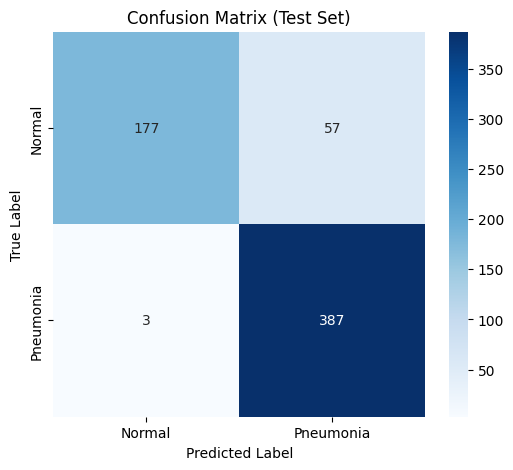


 상세 분류 리포트:
              precision    recall  f1-score   support

      Normal       0.98      0.76      0.86       234
   Pneumonia       0.87      0.99      0.93       390

    accuracy                           0.90       624
   macro avg       0.93      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624



In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==========================================
# 1. 테스트 데이터 로더 생성
# ==========================================
# 테스트 데이터는 검증(Val)과 똑같이 '정규화'만 하고 증강은 하지 않습니다.
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # 평가는 순서대로 해도 됨
    num_workers=2,
    pin_memory=True
)

print(f" 테스트 데이터 개수: {len(test_dataset)}장")

# ==========================================
# 2. 평가 수행 함수
# ==========================================
def evaluate_model(model, loader):
    model.eval() # 평가 모드 전환 (Dropout 끄기 등)

    all_preds = []
    all_labels = []

    print("테스트 셋 평가 중...", end="")

    with torch.no_grad(): # 평가 때는 기울기 계산 불필요 (메모리 절약)
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # 결과를 리스트에 모으기 (CPU로 가져와서)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("완료!")
    return all_labels, all_preds

# ==========================================
# 3. 평가 실행 및 결과 분석
# ==========================================
# (참고) K-Fold 중 가장 마지막에 학습된 모델 상태로 평가합니다.
# 만약 'best_model_wts'를 저장해뒀다면 model.load_state_dict(best_model_wts) 후 실행하세요.
y_true, y_pred = evaluate_model(model, test_loader)

# --- [A] 정확도 (Accuracy) ---
test_acc = accuracy_score(y_true, y_pred)
print(f"\n 최종 테스트 정확도 (Accuracy): {test_acc*100:.2f}%")

# --- [B] 혼동 행렬 시각화 (Confusion Matrix) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# --- [C] 상세 리포트 (Precision, Recall, F1-score) ---
print("\n 상세 분류 리포트:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

## [위결과에 대한 해석]
## 성능 분석 리포트: High Sensitivity Screening Model
1. 핵심 성과: 위음성(False Negative) 최소화 달성
- 지표: Pneumonia Recall 0.99 (Sensitivity, 민감도)
- 해석: 모델이 실제 폐렴 환자(Positive)를 탐지해내는 능력이 매우 탁월합니다.
- 기술적 의미: Type II Error(미탐, Miss)가 거의 0에 수렴하고 있습니다. 이는 의료 진단 보조 시스템(CDSS)의 1차 목표인 "환자를 놓치지 않는 선별(Screening)" 기능을 완벽하게 수행하고 있음을 의미합니다.

2. Trade-off 분석: 위양성(False Positive) 증가
- 지표: Normal Recall 0.76 (Specificity, 특이도 감소) / Pneumonia Precision 0.87
-해석: 모델의 결정 경계(Decision Boundary)가 폐렴 클래스 쪽으로 넓게 설정되었습니다. 이로 인해 정상 데이터(Normal) 중 약 24%를 폐렴으로 오분류(False Positive)하고 있습니다.
-기술적 의미: Type I Error(오경보)가 높습니다. 이는 학습 시 적용한 Class Weight(정상 클래스에 가중치 부여)에도 불구하고, 데이터셋의 다수 클래스(Majority Class)인 폐렴의 특징(Feature)이 더 강하게 학습되었거나, 모델이 보수적인(Conservative) 예측 성향을 가지게 되었음을 시사합니다.

3. F1-Score 및 불균형 처리 평가
- 지표: Weighted Avg F1-Score 0.90
- 해석: 전체적인 조화 평균은 0.90으로 준수합니다. 특히 Pneumonia 클래스의 F1-Score가 0.93으로 매우 높다는 것은 모델이 타겟 클래스(폐렴)에 대해 매우 확신을 가지고 있음을 보여줍니다.
- 결론: 데이터 불균형(1:3) 상황에서 Accuracy 90%를 달성한 것은 Stratified K-Fold와 Weighted Loss 전략이 유효했음을 증명합니다. 단순 편향(Bias)된 모델이라면 Accuracy는 높더라도 Recall이 0에 수렴했을 것입니다.